In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set a plotting style
plt.style.use("ggplot")

In [2]:
customer_df = pd.read_csv("../data/processed/customer_master_clean.csv")

inventory_df = pd.read_csv("../data/processed/inventory_snapshot_clean.csv")

promotions_df = pd.read_csv("../data/processed/promotions_clean.csv")

sales_df = pd.read_csv("../data/processed/sales_transactions_clean.csv")

sku_flags_df = pd.read_csv("../data/processed/sku_inventory_flags_clean.csv")

sku_df = pd.read_csv("../data/processed/sku_master_clean.csv")

store_df = pd.read_csv("../data/processed/store_master_clean.csv")

In [3]:
print("Customer Dataset :", customer_df.shape)
print("Inventory Dataset :", inventory_df.shape)
print("Promotions Dataset :", promotions_df.shape)
print("Sales Dataset :", sales_df.shape)
print("SKU Inventory Flags Dataset :", sku_flags_df.shape)
print("SKU Master Dataset :", sku_df.shape)
print("Store Dataset :", store_df.shape)

Customer Dataset : (10000, 7)
Inventory Dataset : (26408, 6)
Promotions Dataset : (100, 8)
Sales Dataset : (9945511, 11)
SKU Inventory Flags Dataset : (600, 6)
SKU Master Dataset : (5000, 7)
Store Dataset : (30, 5)


In [4]:
display(customer_df.head())
display(inventory_df.head())
display(promotions_df.head())
display(sales_df.head())
display(sku_flags_df.head())
display(sku_df.head())
display(store_df.head())

,cust_id,age,gender,city,loyalty_segment,preferred_channel,registration_date
0,CUST00001,52,Female,Sukkur,Silver,Online,2021-01-01
1,CUST00002,41,Female,Karachi,Silver,Mobile App,2021-05-14
2,CUST00003,48,Female,Bahawalpur,Bronze,In-Store,2022-10-23
3,CUST00004,45,Male,Karachi,Silver,In-Store,2015-07-15
4,CUST00005,39,Female,Faisalabad,Bronze,In-Store,2024-01-02


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,333,72,22,2025-06-23
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,496,96,34,2025-07-10
3,ST19,SKU02907,109,34,13,2025-08-17
4,ST05,SKU01023,333,97,22,2025-07-12


,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO001,Spring Discount Days,2024-07-28,2024-08-02,15.1,BOGO,Brand,NovaFresh
1,PROMO002,Summer Savings Event,2023-03-09,2023-03-21,7.0,Bundle Offer,All,All
2,PROMO003,Payday Discount Days,2025-04-30,2025-05-26,10.2,BOGO,Brand,ZestyCo
3,PROMO004,Super Sale,2025-06-07,2025-06-17,15.9,Clearance,SKU,SKU01108
4,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,Bundle Offer,All,All


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN


,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU04321,STOCKOUT_RISK,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-11-06,2025-12-03,Top-selling SKU (by observed volume); injected...
1,SKU04596,STOCKOUT_RISK,ST12;ST09;ST21;ST23;ST07;ST24;ST01;ST28;ST14;S...,2025-10-25,2025-11-06,Top-selling SKU (by observed volume); injected...
2,SKU03727,STOCKOUT_RISK,ST19;ST14;ST28;ST29;ST02;ST07;ST17;ST08;ST05;ST16,2025-11-08,2025-11-29,Top-selling SKU (by observed volume); injected...
3,SKU04154,STOCKOUT_RISK,ST15;ST03;ST30;ST09;ST24;ST19;ST28;ST02;ST07;S...,2025-11-12,2025-11-26,Top-selling SKU (by observed volume); injected...
4,SKU00953,STOCKOUT_RISK,ST09;ST19;ST27;ST20;ST01;ST03;ST11;ST10;ST22;S...,2025-11-29,2025-12-25,Top-selling SKU (by observed volume); injected...


,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch
3,SKU00004,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,233.64,156.32,SunriseFoods
4,SKU00005,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,138.50,83.46,SunriseFoods


,store_id,store_name,city,store_type,opening_date
0,ST01,Quetta Convenience Store #01,Quetta,Convenience Store,2017-07-08
1,ST02,Islamabad Express Store #02,Islamabad,Express Store,2019-05-08
2,ST03,Sialkot Supermarket #03,Sialkot,Supermarket,2019-03-28
3,ST04,Multan Supermarket #04,Multan,Supermarket,2017-10-08
4,ST05,Karachi Supermarket #05,Karachi,Supermarket,2020-11-03


In [5]:
customer_df = pd.read_csv("../data/processed/customer_master_clean.csv")
inventory_df = pd.read_csv("../data/processed/inventory_snapshot_clean.csv")
promotions_df = pd.read_csv("../data/processed/promotions_clean.csv")
sales_df = pd.read_csv("../data/processed/sales_transactions_clean.csv")
sku_flags_df = pd.read_csv("../data/processed/sku_inventory_flags_clean.csv")
sku_df = pd.read_csv("../data/processed/sku_master_clean.csv")
store_df = pd.read_csv("../data/processed/store_master_clean.csv")

In [6]:
print("Customer:", customer_df.shape)
print("Inventory:", inventory_df.shape)
print("Promotions:", promotions_df.shape)
print("Sales:", sales_df.shape)
print("SKU Inventory Flags:", sku_flags_df.shape)
print("SKU Master:", sku_df.shape)
print("Store:", store_df.shape)

Customer: (10000, 7)
Inventory: (26408, 6)
Promotions: (100, 8)
Sales: (9945511, 11)
SKU Inventory Flags: (600, 6)
SKU Master: (5000, 7)
Store: (30, 5)


In [7]:
sales_df.head()

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN


In [8]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9945511 entries, 0 to 9945510
Data columns (total 11 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          str    
 1   receipt_id    str    
 2   store_id      str    
 3   sku_id        str    
 4   customer_id   str    
 5   quantity      int64  
 6   unit_price    float64
 7   total_value   float64
 8   channel       str    
 9   discount_pct  float64
 10  promo_id      str    
dtypes: float64(3), int64(1), str(7)
memory usage: 834.7 MB


In [9]:
sales_df["date"] = pd.to_datetime(sales_df["date"])

In [10]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9945511 entries, 0 to 9945510
Data columns (total 11 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[us]
 1   receipt_id    str           
 2   store_id      str           
 3   sku_id        str           
 4   customer_id   str           
 5   quantity      int64         
 6   unit_price    float64       
 7   total_value   float64       
 8   channel       str           
 9   discount_pct  float64       
 10  promo_id      str           
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 834.7 MB


In [11]:
sales_df.describe()

,date,quantity,unit_price,total_value,discount_pct
count,9945511,9.945511e+06,9.945511e+06,9.945511e+06,9.945511e+06
mean,2024-02-04 20:18:18.654136,1.880336e+00,6.215749e+02,1.094512e+03,6.289965e+00
min,2022-01-01 00:00:00,1.000000e+00,2.441000e+01,1.225000e+01,0.000000e+00
25%,2023-02-05 00:00:00,1.000000e+00,1.734300e+02,2.351700e+02,0.000000e+00
50%,2024-02-12 00:00:00,2.000000e+00,3.367200e+02,5.432000e+02,0.000000e+00
75%,2025-01-28 00:00:00,3.000000e+00,9.256700e+02,1.277610e+03,0.000000e+00
max,2025-12-31 00:00:00,5.000000e+00,4.755470e+03,2.377735e+04,4.980000e+01
std,NaN,1.089063e+00,6.751952e+02,1.536814e+03,1.383267e+01


In [12]:
sales_df.isnull().sum()

date                  0
receipt_id            0
store_id              0
sku_id                0
customer_id           0
quantity              0
unit_price            0
total_value           0
channel               0
discount_pct          0
promo_id        7855345
dtype: int64

In [13]:
daily_sales = (
    sales_df.groupby("date")["total_value"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,total_value
0,2022-01-01,5803048.93
1,2022-01-02,5933508.44
2,2022-01-03,6041608.01
3,2022-01-04,5847850.64
4,2022-01-05,5832333.56


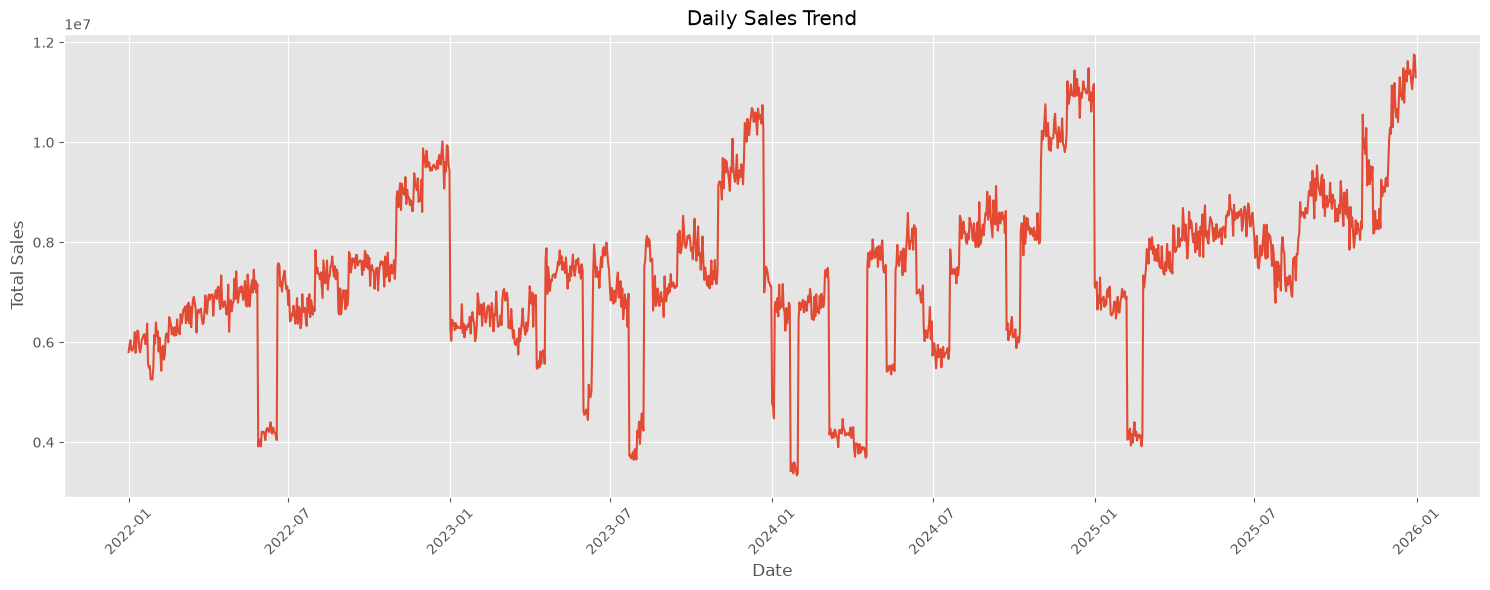

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_value"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [15]:
monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="date", freq="ME"))["total_value"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,date,total_value
0,2022-01-31,1.820395e+08
1,2022-02-28,1.710435e+08
2,2022-03-31,2.042833e+08
3,2022-04-30,2.050013e+08
4,2022-05-31,2.063285e+08


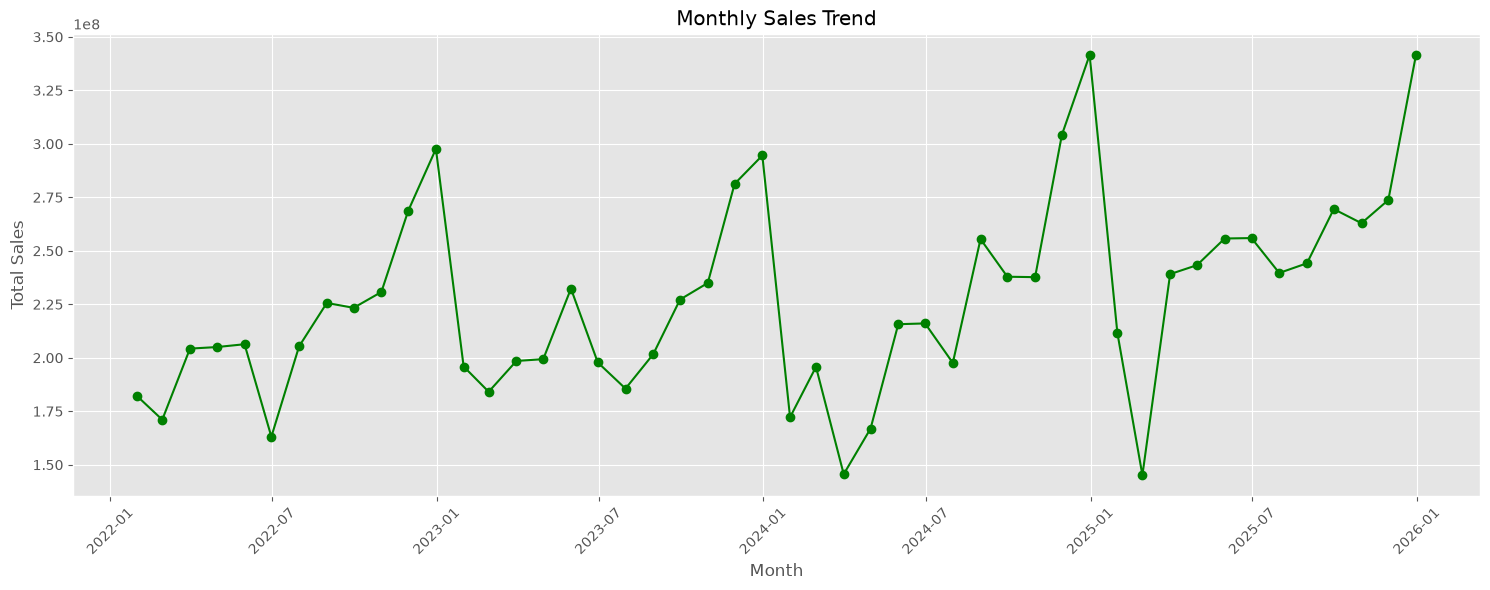

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["total_value"],
    marker="o",
    color="green"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
top_skus = (
    sales_df.groupby("sku_id")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_skus

,sku_id,total_value
0,SKU04321,1.069036e+09
1,SKU03727,2.599450e+08
2,SKU04329,9.419997e+07
3,SKU04596,8.881353e+07
4,SKU03053,8.354538e+07
5,SKU01371,8.312455e+07
6,SKU01189,6.942638e+07
7,SKU04551,6.879118e+07
8,SKU04157,6.873643e+07
9,SKU04571,6.218228e+07


In [18]:
top_skus = top_skus.merge(
    sku_df[["sku_id", "sku_name"]],
    on="sku_id",
    how="left"
)

top_skus

,sku_id,total_value,sku_name
0,SKU04321,1.069036e+09,EliteHome Hair Care Pack of 6
1,SKU03727,2.599450e+08,QuickBite Mobile Accessories 2kg
2,SKU04329,9.419997e+07,SoftTouch Cookware 2kg
3,SKU04596,8.881353e+07,ValueChoice Eggs Pack of 6
4,SKU03053,8.354538e+07,PremiumSelect Kids Wear Family Pack
5,SKU01371,8.312455e+07,PureLife Cookware 1L
6,SKU01189,6.942638e+07,PureLife Footwear 500g
7,SKU04551,6.879118e+07,DailyBest Cookware Small
8,SKU04157,6.873643e+07,PremiumSelect Small Appliances 1L
9,SKU04571,6.218228e+07,EliteHome Ready Meals 250g


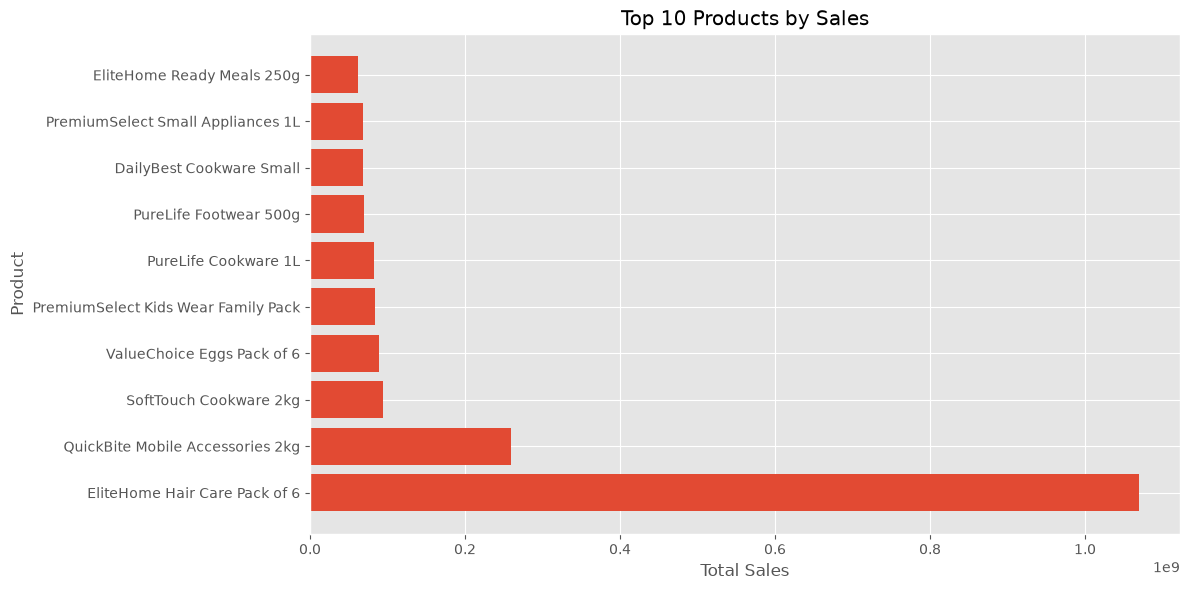

In [19]:
plt.figure(figsize=(12,6))

plt.barh(
    top_skus["sku_name"],
    top_skus["total_value"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [20]:
top_stores = (
    sales_df.groupby("store_id")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_stores

,store_id,total_value
0,ST06,5.173807e+08
1,ST07,5.172363e+08
2,ST29,5.166807e+08
3,ST22,5.149640e+08
4,ST20,5.147034e+08
5,ST21,5.130012e+08
6,ST30,5.128304e+08
7,ST05,3.892746e+08
8,ST18,3.888976e+08
9,ST04,3.878632e+08


In [21]:
top_stores = top_stores.merge(
    store_df[["store_id", "store_name"]],
    on="store_id",
    how="left"
)

top_stores

,store_id,total_value,store_name
0,ST06,5.173807e+08,Sukkur Hypermarket #06
1,ST07,5.172363e+08,Peshawar Hypermarket #07
2,ST29,5.166807e+08,Karachi Hypermarket #29
3,ST22,5.149640e+08,Islamabad Hypermarket #22
4,ST20,5.147034e+08,Multan Hypermarket #20
5,ST21,5.130012e+08,Peshawar Hypermarket #21
6,ST30,5.128304e+08,Multan Hypermarket #30
7,ST05,3.892746e+08,Karachi Supermarket #05
8,ST18,3.888976e+08,Karachi Supermarket #18
9,ST04,3.878632e+08,Multan Supermarket #04


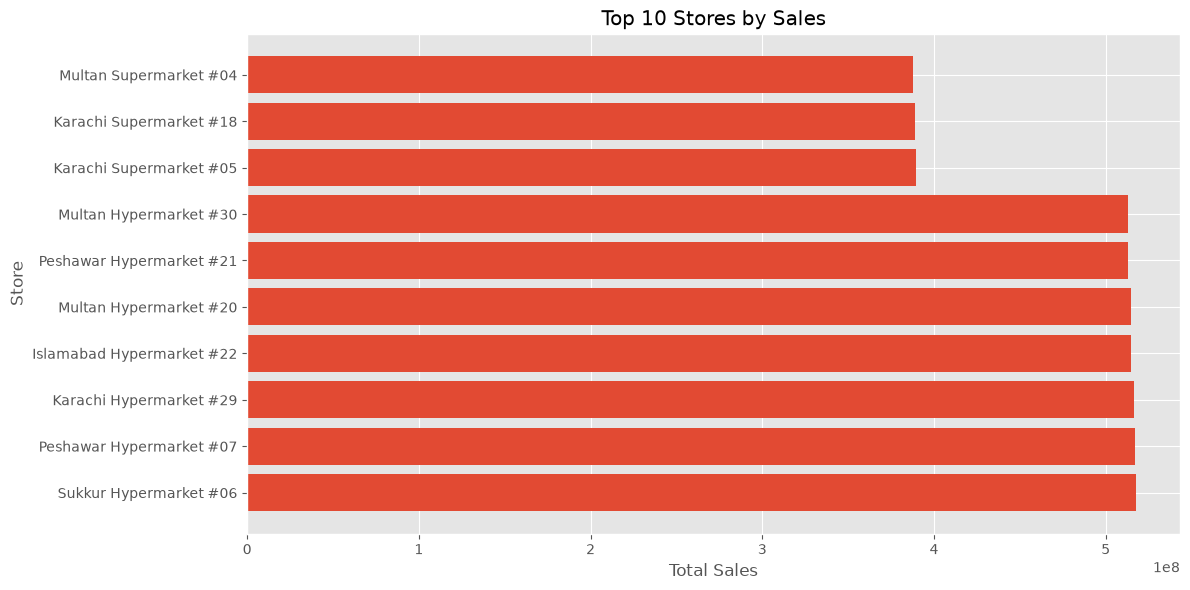

In [22]:
plt.figure(figsize=(12,6))

plt.barh(
    top_stores["store_name"],
    top_stores["total_value"]
)

plt.title("Top 10 Stores by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Store")

plt.tight_layout()
plt.show()

In [23]:
channel_sales = (
    sales_df.groupby("channel")["total_value"]
    .sum()
    .reset_index()
)

channel_sales

,channel,total_value
0,In-Store,6.014943e+09
1,Mobile App,1.633258e+09
2,Online,3.237278e+09


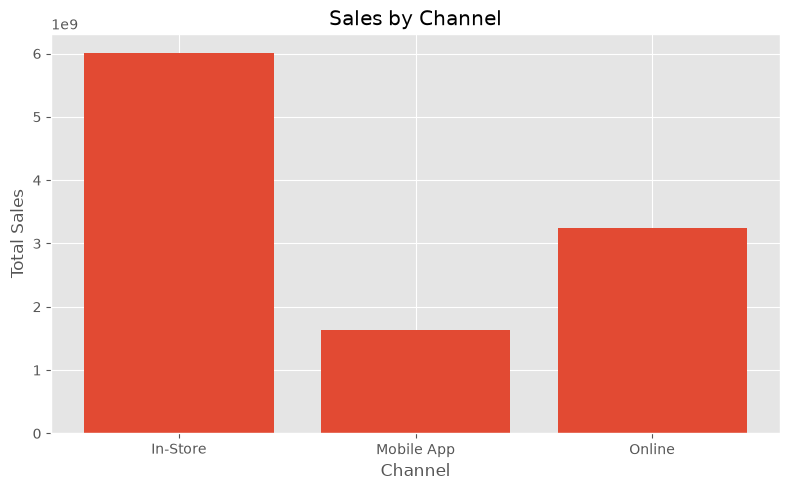

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    channel_sales["channel"],
    channel_sales["total_value"]
)

plt.title("Sales by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [25]:
sales_category = sales_df.merge(
    sku_df[["sku_id", "category"]],
    on="sku_id",
    how="left"
)

In [26]:
category_sales = (
    sales_category.groupby("category")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,category,total_value
0,Electronics & Accessories,2.328292e+09
1,Apparel & Footwear,1.911954e+09
2,Personal Care,1.618258e+09
3,Home & Kitchen,1.578784e+09
4,Health & Wellness,8.889558e+08
5,Frozen Foods,8.136173e+08
6,Home Care,4.220981e+08
7,Dairy & Bakery,3.511117e+08
8,Grocery,3.493301e+08
9,Stationery & Office,3.093953e+08


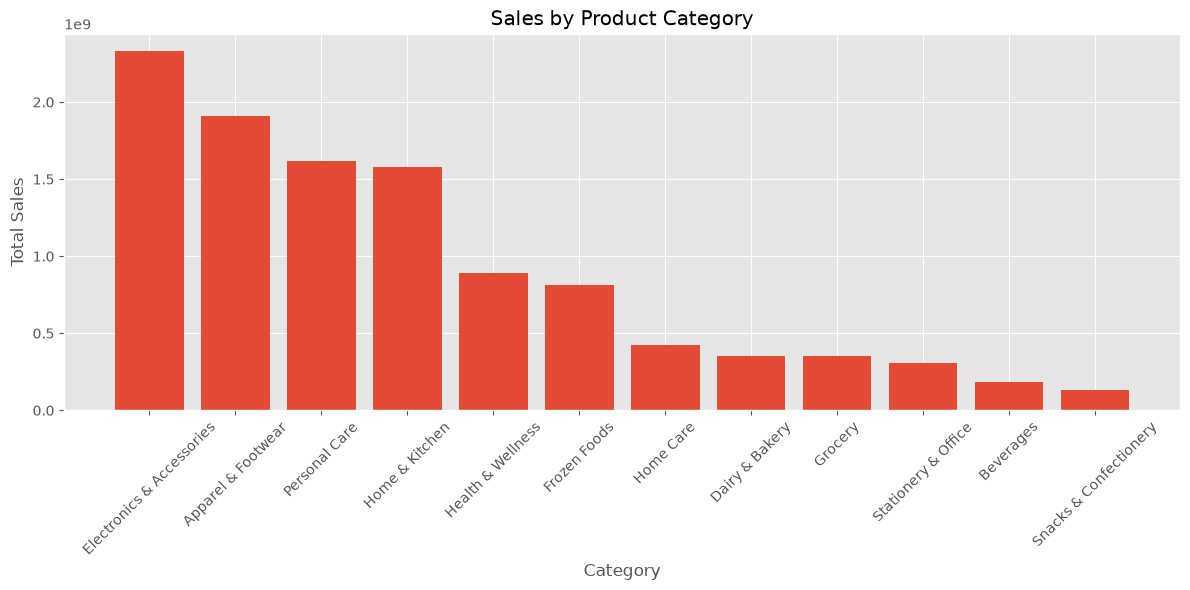

In [27]:
plt.figure(figsize=(12,6))

plt.bar(
    category_sales["category"],
    category_sales["total_value"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
sales_customer = sales_df.merge(
    customer_df[["cust_id", "loyalty_segment"]],
    left_on="customer_id",
    right_on="cust_id",
    how="left"
)

In [29]:
loyalty_sales = (
    sales_customer.groupby("loyalty_segment")["total_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

loyalty_sales

,loyalty_segment,total_value
0,Silver,3.053781e+09
1,Gold,2.804550e+09
2,Bronze,2.724371e+09
3,Platinum,2.302777e+09


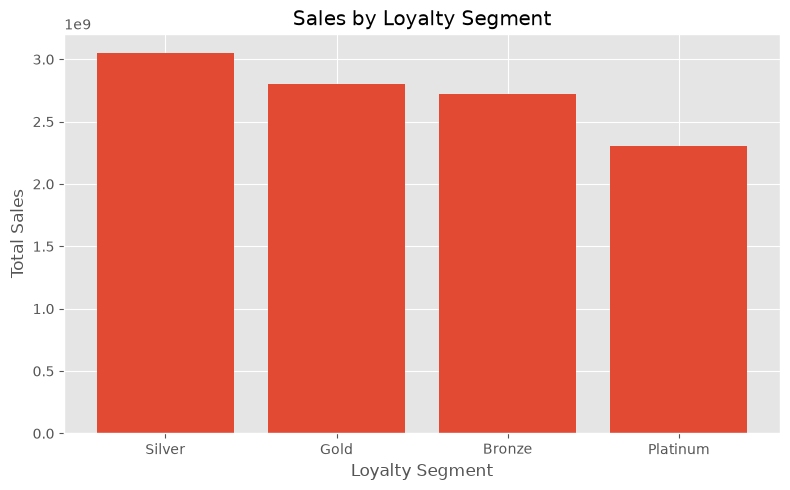

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    loyalty_sales["loyalty_segment"],
    loyalty_sales["total_value"]
)

plt.title("Sales by Loyalty Segment")
plt.xlabel("Loyalty Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [31]:
inventory_df[["stock_on_hand", "reorder_point", "safety_stock"]].describe()

,stock_on_hand,reorder_point,safety_stock
count,26408.000000,26408.000000,26408.000000
mean,166.195812,59.983301,20.951719
std,142.238780,23.389128,9.873781
min,0.000000,20.000000,4.000000
25%,40.000000,40.000000,13.000000
50%,140.000000,60.000000,20.000000
75%,264.000000,80.000000,28.000000
max,598.000000,100.000000,50.000000


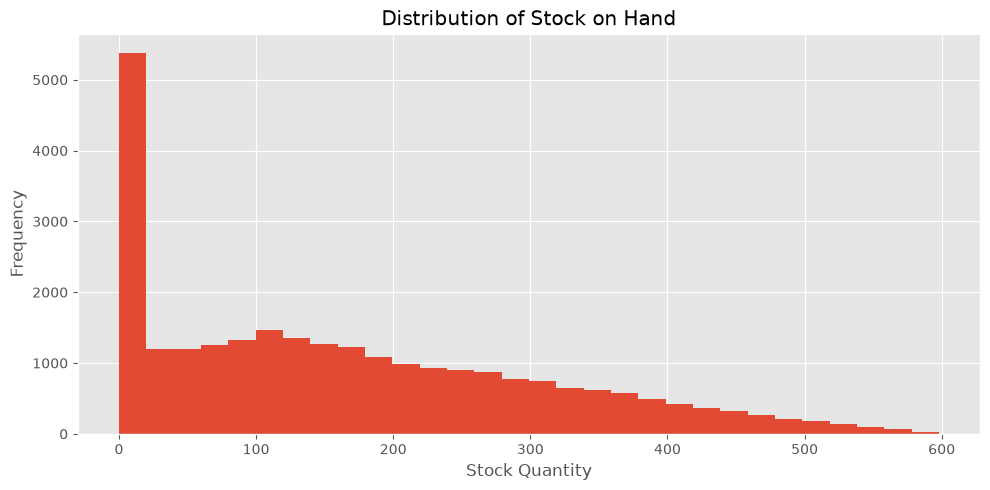

In [32]:
plt.figure(figsize=(10,5))

plt.hist(inventory_df["stock_on_hand"], bins=30)

plt.title("Distribution of Stock on Hand")
plt.xlabel("Stock Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [33]:
inventory_df["below_reorder"] = (
    inventory_df["stock_on_hand"] <
    inventory_df["reorder_point"]
)

In [34]:
inventory_df["below_reorder"].value_counts()

below_reorder
False    19307
True      7101
Name: count, dtype: int64

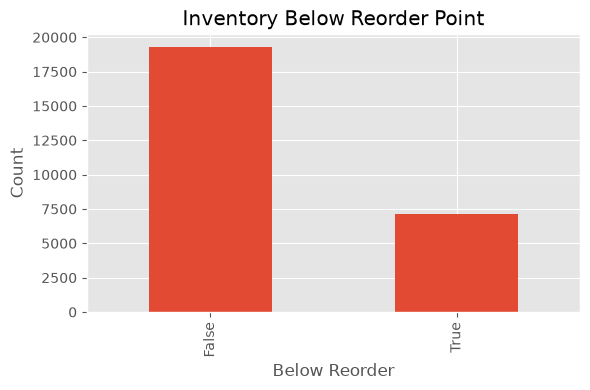

In [35]:
inventory_df["below_reorder"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Inventory Below Reorder Point")
plt.xlabel("Below Reorder")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [36]:
sales_df["promo_id"].notna().value_counts()

promo_id
False    7855345
True     2090166
Name: count, dtype: int64

In [37]:
promo_percentage = (
    sales_df["promo_id"].notna().mean() * 100
)

print(f"Sales using promotions: {promo_percentage:.2f}%")

Sales using promotions: 21.02%


In [38]:
sales_df.groupby(
    sales_df["promo_id"].notna()
)["total_value"].mean()

promo_id
False    1164.002053
True      833.350933
Name: total_value, dtype: float64

In [39]:
sku_flags_df["flag"].value_counts()

flag
SLOW_MOVER       400
STOCKOUT_RISK    200
Name: count, dtype: int64

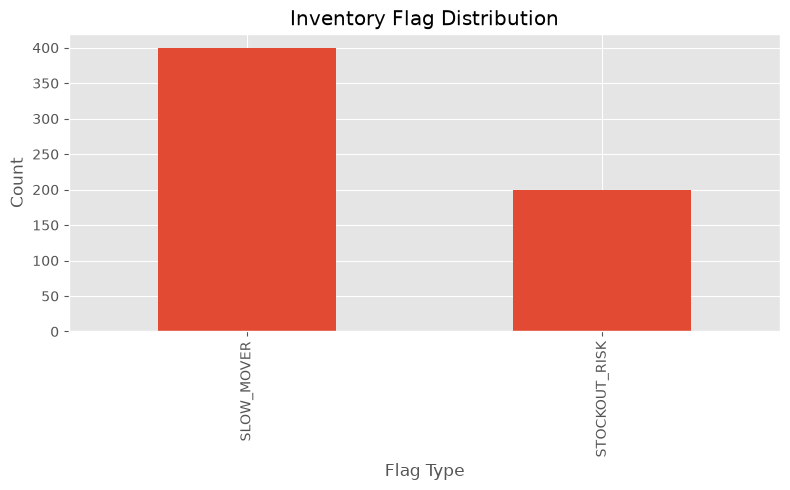

In [40]:
plt.figure(figsize=(8,5))

sku_flags_df["flag"].value_counts().plot(kind="bar")

plt.title("Inventory Flag Distribution")
plt.xlabel("Flag Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [41]:
# Total quantity sold by SKU

sku_sales = sales_df.groupby("sku_id")["quantity"].sum().reset_index()

sku_sales.rename(columns={"quantity": "total_quantity_sold"}, inplace=True)

# Merge with SKU master

dead_stock = sku_df.merge(sku_sales, on="sku_id", how="left")

dead_stock["total_quantity_sold"] = dead_stock["total_quantity_sold"].fillna(0)

# Products with zero sales

dead_stock_items = dead_stock[dead_stock["total_quantity_sold"] == 0]

print("Number of Dead Stock Products:", dead_stock_items.shape[0])

dead_stock_items.head(10)

Number of Dead Stock Products: 0


,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand,total_quantity_sold


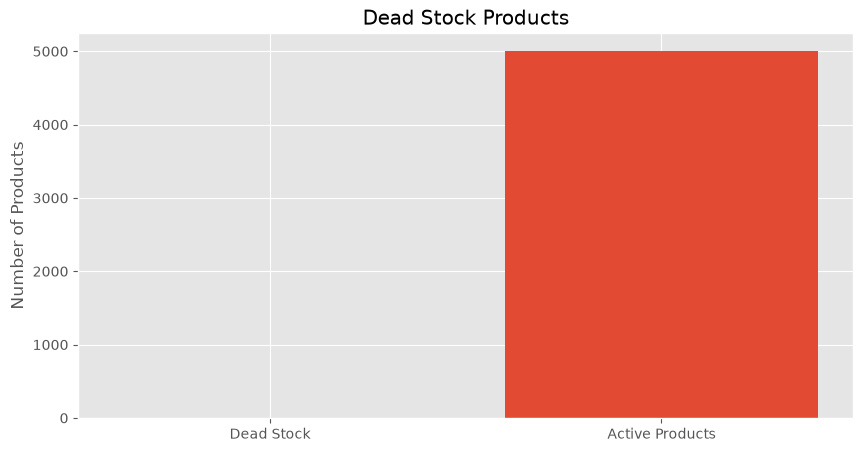

In [42]:
plt.figure(figsize=(10,5))

plt.bar(
    ["Dead Stock", "Active Products"],
    [
        dead_stock_items.shape[0],
        dead_stock.shape[0] - dead_stock_items.shape[0]
    ]
)

plt.title("Dead Stock Products")
plt.ylabel("Number of Products")

plt.show()

# Business Insights

## Key Findings

### 1. Sales exhibit clear time-based trends
Daily and monthly sales analysis indicates that customer demand varies over time. This suggests that seasonality and historical demand patterns should be incorporated into the forecasting model.

---

### 2. A small group of SKUs contributes significantly to total sales
The Top 10 Selling Products analysis shows that a limited number of products generate a large share of overall revenue. These high-performing SKUs should receive priority in demand forecasting and inventory planning.

---

### 3. Sales performance differs across stores
Store-level analysis reveals variation in sales across locations. High-performing stores require more frequent inventory replenishment, while lower-performing stores may benefit from optimized stock allocation.

---

### 4. Customer purchasing behavior varies by sales channel
Sales are distributed across Online, In-Store, and Mobile App channels. Understanding channel-wise demand helps businesses optimize inventory availability and improve customer experience.

---

### 5. Product categories contribute differently to revenue
Some product categories generate substantially higher sales than others. Category-level insights enable better assortment planning, inventory investment, and promotional strategies.

---

### 6. Loyal customers contribute significantly to sales
Sales by loyalty segment indicate that repeat customers play an important role in overall revenue generation. Retention programs and personalized promotions can further improve customer lifetime value.

---

### 7. Inventory monitoring supports proactive stock management
Inventory analysis identifies products approaching their reorder points and highlights current stock availability. Monitoring these metrics helps reduce the risk of stockouts.

---

### 8. Promotional campaigns influence product sales
Promotion analysis provides visibility into discount campaigns and promotional activity. These insights can be used to evaluate promotion effectiveness and support future marketing decisions.

---

### 9. Several SKUs are currently flagged for inventory risk
The SKU Inventory Flags dataset identifies products with elevated stockout risk across multiple stores. These products should receive priority during replenishment planning.

---

### 10. No dead stock products were identified
Dead stock analysis shows that every SKU has recorded at least one sale during the available time period. This indicates healthy product movement across the catalog, although future datasets should continue monitoring for slow-moving inventory.

---

## Overall Conclusion

The exploratory data analysis provides a comprehensive understanding of sales performance, customer behavior, inventory status, and promotional activity. These insights establish a strong foundation for the next phase of the project, where feature engineering and demand forecasting models will be developed to support intelligent inventory planning and business decision-making.